# Stock Price Prediction using HMM, LSTM, ARIMA, and RNN

In this notebook, we will predict stock prices using various methods including Hidden Markov Model (HMM), Long Short-Term Memory (LSTM), AutoRegressive Integrated Moving Average (ARIMA), and Recurrent Neural Network (RNN). We will compare the performance of these models using various error metrics.


In [2]:
# Import necessary libraries for data manipulation, model building, and evaluation

from hmmlearn import hmm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


from evaluationFuncs import mape, rmse, direction_accuracy

from modelFuncs import dataExtracterMonths, dataExtracterDays, HMMPricePredictor

## Load and Prepare Data

In this section, we load the data and preprocess it for modeling.


In [3]:
def feature_prep(df):
    df['Return'] = df['Close'].pct_change()
    df['LogReturn'] = np.log(1 + df['Return'])
    df['Volatility'] = df['Return'].rolling(10).std()
    df['Momentum'] = df['Close'].pct_change(5)
    df = df.dropna()
    return df

df_nvo = dataExtracterDays('NVO', '2016-01-01', '2026-01-01')
df_nvo

[*********************100%***********************]  1 of 1 completed

The dataset has observations across 2514 days


,Date,Open,High,Low,Close
0,2016-01-04,23.377440,23.385530,22.952690,23.179222
1,2016-01-05,23.450250,23.527109,23.292486,23.454294
2,2016-01-06,23.078086,23.300574,23.053816,23.175173
3,2016-01-07,22.693791,22.839420,22.511756,22.673565
4,2016-01-08,22.665473,22.709971,22.099141,22.151728
...,...,...,...,...,...
2509,2025-12-24,52.849998,53.630001,52.000000,52.560001
2510,2025-12-26,53.020000,53.029999,51.700001,52.400002
2511,2025-12-29,51.560001,51.990002,51.349998,51.470001
2512,2025-12-30,51.520000,51.669998,51.070000,51.220001


In [4]:
df_nvo = feature_prep(df_nvo)
df_nvo

,Date,Open,High,Low,Close,Return,LogReturn,Volatility,Momentum
10,2016-01-19,21.714841,21.755293,21.391222,21.520670,0.001506,0.001505,0.018116,-0.024390
11,2016-01-20,21.172782,21.565170,20.857253,21.395269,-0.005827,-0.005844,0.016862,-0.045823
12,2016-01-21,21.613710,21.735067,21.346724,21.569212,0.008130,0.008097,0.017653,-0.014964
13,2016-01-22,21.917103,22.248812,21.900921,22.143637,0.026632,0.026283,0.019691,-0.004003
14,2016-01-25,22.289267,22.588615,22.204317,22.353991,0.009500,0.009455,0.018519,0.040286
...,...,...,...,...,...,...,...,...,...
2509,2025-12-24,52.849998,53.630001,52.000000,52.560001,0.018407,0.018240,0.028437,0.100272
2510,2025-12-26,53.020000,53.029999,51.700001,52.400002,-0.003044,-0.003049,0.027850,0.100609
2511,2025-12-29,51.560001,51.990002,51.349998,51.470001,-0.017748,-0.017907,0.028685,0.070285
2512,2025-12-30,51.520000,51.669998,51.070000,51.220001,-0.004857,-0.004869,0.028786,0.064865


## Hidden Markov Model (HMM)

We will implement the HMM to predict future stock prices.

In [5]:
def HMM_predict(obsData, train_size, window_size, Ncomp, doprint=False):
    rng = np.random.default_rng(123)
    obs = obsData.copy()
    train = obs[:train_size]
    features = ['LogReturn', 'Volatility', 'Momentum']
    train_data = train[features].values
    
    train_scaled = scaler.fit_transform(train_data)
    # Train global HMM
    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_scaled)
    
    means = model.means_
    stds = np.sqrt(model._covars_)
    first = True
    if doprint:
        print("State-wise means:", np.round(means.flatten(), 3))
        print("State-wise std:", stds.flatten())
        print("State counts:", np.bincount(model.predict(train_scaled)))
        print(np.sum(np.isnan(train_data)))
        print(np.round(model.transmat_, 2))
        first = True
    
    T = max(window_size, train_size)
    predictions = []
    returns = []
    while T < len(obs):
        window = obs[features].iloc[T-window_size:T].values
        window_scaled = scaler.transform(window)

        # Predict the current state based on the most recent window
        current_state = model.predict(window_scaled)[-1]

        # Choose the most likely next state based on transition probabilities
        next_state = rng.choice(np.where(model.transmat_[current_state] == np.max(model.transmat_[current_state]))[0])  

        # Sample a return from the predicted next state
        predicted_return_scaled = rng.normal(loc=means[next_state][0], scale=stds[next_state][0])

        dummy = np.zeros((1, len(features)))
        dummy[0, 0] = predicted_return_scaled

        predicted_log_return = scaler.inverse_transform(dummy)[0, 0]
        

        # Convert to price
        last_price = obs['Close'].iloc[T-1]
        predicted_price = last_price * np.exp(predicted_log_return)
        if first:
            print(f"Date for day before first prediction: {obs['Date'].iloc[T-1]}")
            print(f"Date for first day of real data: {obs['Date'].iloc[train_size]}")
            first = False

        returns.append(predicted_log_return)
        predictions.append(predicted_price)
        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns

In [6]:
def HMM_predict_other(obsTrain, obsPred, window_size, Ncomp, doprint=False):
    rng = np.random.default_rng(123)
    train = obsTrain.copy()
    features = ['LogReturn', 'Volatility', 'Momentum']
    train_data = train[features].values
    
    train_scaled = scaler.fit_transform(train_data)
    # Train global HMM
    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_scaled)
    
    means = model.means_
    stds = np.sqrt(model._covars_)
    first = True
    if doprint:
        print("State-wise means:", np.round(means.flatten(), 3))
        print("State-wise std:", stds.flatten())
        print("State counts:", np.bincount(model.predict(train_scaled)))
        print(np.sum(np.isnan(train_data)))
        print(np.round(model.transmat_, 2))
        first = True
    
    T = window_size
    predictions = []
    returns = []
    while T < len(obsPred):
        window = obsPred[features].iloc[T-window_size:T].values
        window_scaled = scaler.transform(window)

        # Predict the current state based on the most recent window
        current_state = model.predict(window_scaled)[-1]

        # Choose the most likely next state based on transition probabilities
        next_state = rng.choice(np.where(model.transmat_[current_state] == np.max(model.transmat_[current_state]))[0])  

        # Sample a return from the predicted next state
        predicted_return_scaled = rng.normal(loc=means[next_state][0], scale=stds[next_state][0])

        dummy = np.zeros((1, len(features)))
        dummy[0, 0] = predicted_return_scaled

        predicted_log_return = scaler.inverse_transform(dummy)[0, 0]
        

        # Convert to price
        last_price = obsPred['Close'].iloc[T-1]
        predicted_price = last_price * np.exp(predicted_log_return)
        if first:
            print(f"Date for day before first prediction: {obsPred['Date'].iloc[T-1]}")
            print(f"Date for first day of real data: {obsPred['Date'].iloc[window_size]}")
            first = False

        returns.append(predicted_log_return)
        predictions.append(predicted_price)
        T += 1

    close = obsPred['Close'].iloc[window_size:].values

    return predictions, close, returns

In [7]:
def HMM_predict_multi(train_dfs, obsPred, window_size, Ncomp, doprint=False):
    rng = np.random.default_rng(123)
    combined_train = pd.concat(train_dfs, ignore_index=True)
    features = ['LogReturn', 'Volatility', 'Momentum']
    train_data = combined_train[features].values
    lengths = [len(df) for df in train_dfs]
    
    train_scaled = scaler.fit_transform(train_data)
    # Train global HMM
    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_scaled, lengths)
    
    means = model.means_
    stds = np.sqrt(model._covars_)
    first = True
    if doprint:
        print("State-wise means:", np.round(means.flatten(), 3))
        print("State-wise std:", stds.flatten())
        print("State counts:", np.bincount(model.predict(train_scaled)))
        print(np.sum(np.isnan(train_data)))
        print(np.round(model.transmat_, 2))
        first = True
    
    T = window_size
    predictions = []
    returns = []
    while T < len(obsPred):
        window = obsPred[features].iloc[T-window_size:T].values
        window_scaled = scaler.transform(window)

        # Predict the current state based on the most recent window
        current_state = model.predict(window_scaled)[-1]

        # Choose the most likely next state based on transition probabilities
        next_state = rng.choice(np.where(model.transmat_[current_state] == np.max(model.transmat_[current_state]))[0])  

        # Sample a return from the predicted next state
        predicted_return_scaled = rng.normal(loc=means[next_state][0], scale=stds[next_state][0])

        dummy = np.zeros((1, len(features)))
        dummy[0, 0] = predicted_return_scaled

        predicted_log_return = scaler.inverse_transform(dummy)[0, 0]
        

        # Convert to price
        last_price = obsPred['Close'].iloc[T-1]
        predicted_price = last_price * np.exp(predicted_log_return)
        if first:
            print(f"Date for day before first prediction: {obsPred['Date'].iloc[T-1]}")
            print(f"Date for first day of real data: {obsPred['Date'].iloc[window_size]}")
            first = False

        returns.append(predicted_log_return)
        predictions.append(predicted_price)
        T += 1

    close = obsPred['Close'].iloc[window_size:].values

    return predictions, close, returns

In [8]:
df_SP = dataExtracterDays('^GSPC', '2022-01-01', '2024-01-01')
df_SP = feature_prep(df_SP)
tickers = ['LLY', 'PFE', 'MRK', 'JNJ', 'SNY', 'AZN']
df_list = []
for ticker in tickers:
    df = dataExtracterDays(ticker, '2022-01-01', '2024-01-01')
    df = feature_prep(df)
    df_list.append(df)
df_nvo = dataExtracterDays('NVO', '2022-01-01', '2026-01-01')
df_nvo = feature_prep(df_nvo)

[*********************100%***********************]  1 of 1 completed

The dataset has observations across 501 days


[*********************100%***********************]  1 of 1 completed


The dataset has observations across 501 days


[*********************100%***********************]  1 of 1 completed


...

The dataset has observations across 501 days


[*********************100%***********************]  1 of 1 completed


The dataset has observations across 501 days


[*********************100%***********************]  1 of 1 completed

The dataset has observations across 1003 days


In [9]:
Ntrain = len(df_SP)
print(Ntrain)
Nwindow = 30
NStates = 7

NVO_predictions_logfeat, real_logfeat, predReturns_logfeat = HMM_predict(df_nvo, train_size=Ntrain, window_size=Nwindow, Ncomp=NStates, doprint=False)
NVO_pred_other, real_other, predReturns_other = HMM_predict_other(df_SP, df_nvo[Ntrain-Nwindow:], window_size=Nwindow, Ncomp=NStates, doprint=False)
NVO_pred_multi, real_multi, predReturns_multi = HMM_predict_multi(df_list, df_nvo[Ntrain-Nwindow:], window_size=Nwindow, Ncomp=NStates, doprint=False)

491


c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Date for day before first prediction: 2023-12-29
Date for first day of real data: 2024-01-02


c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Date for day before first prediction: 2023-12-29
Date for first day of real data: 2024-01-02
Date for day before first prediction: 2023-12-29
Date for first day of real data: 2024-01-02


## Plot Predictions

Now, we plot the predictions from all models alongside the actual observed prices.


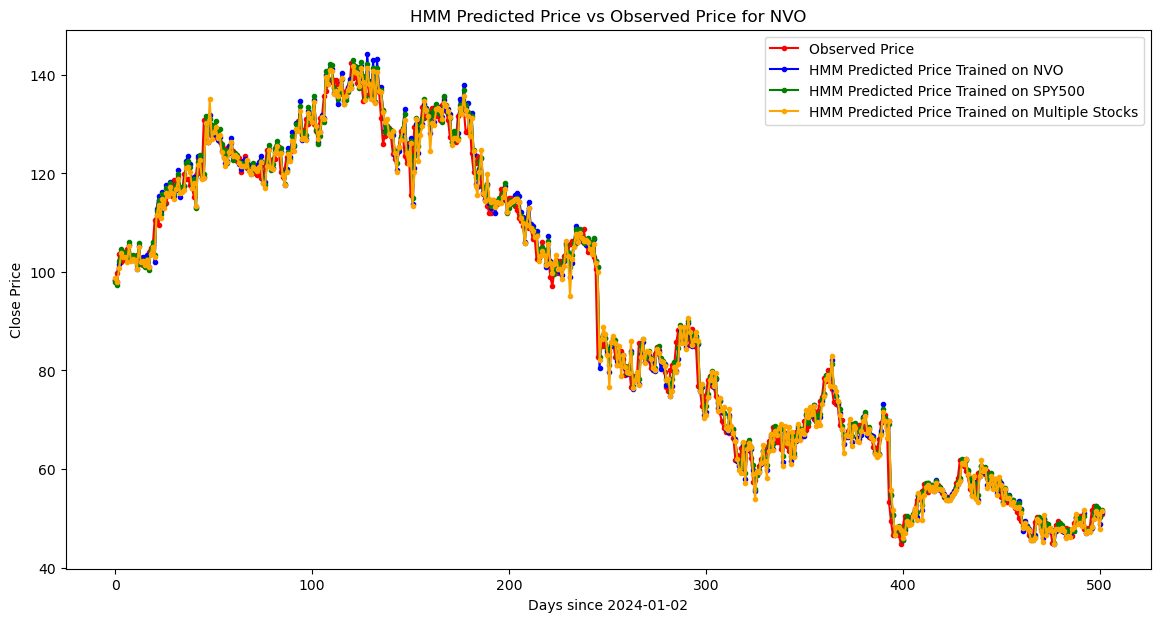

In [10]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot actual prices for the corresponding period
ax.plot(real_logfeat, marker='.', label='Observed Price', color='red')
ax.plot(NVO_predictions_logfeat, marker='.', label='HMM Predicted Price Trained on NVO', color='blue')
ax.plot(NVO_pred_other, marker='.', label='HMM Predicted Price Trained on SPY500', color='green')
ax.plot(NVO_pred_multi, marker='.', label='HMM Predicted Price Trained on Multiple Stocks', color='orange')
ax.set_ylabel("Close Price")
ax.set_xlabel(f"Days since {df_nvo['Date'].iloc[Ntrain]}")
ax.legend();
ax.set_title(f"HMM Predicted Price vs Observed Price for NVO");

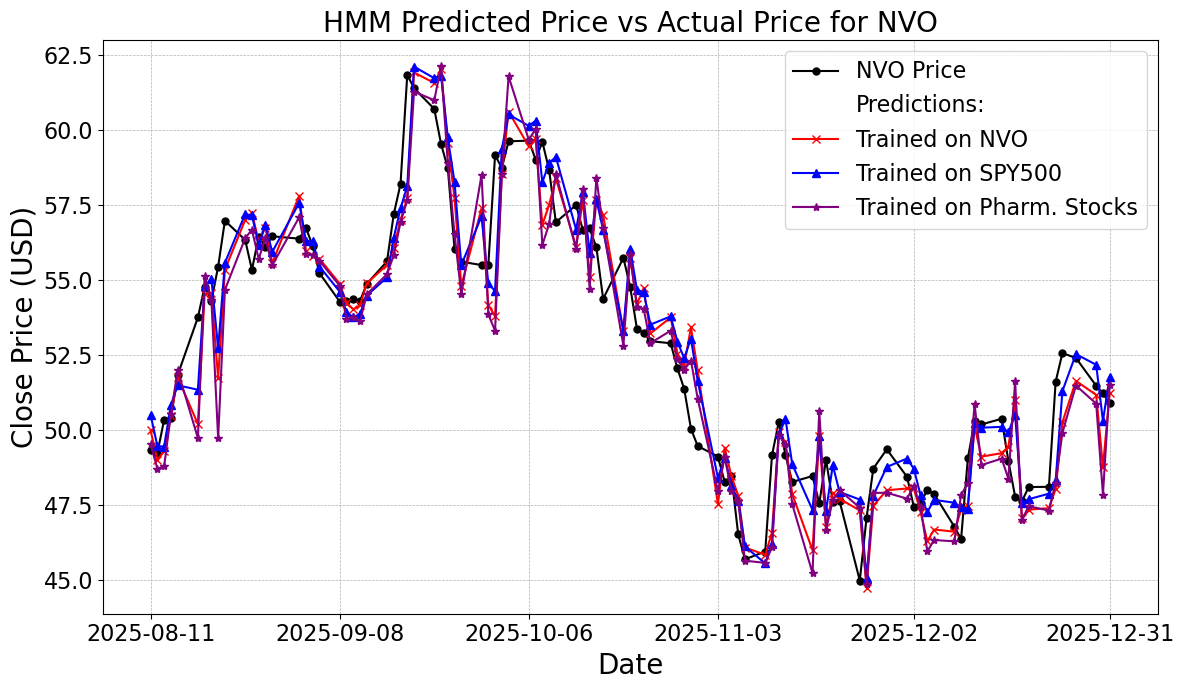

In [ ]:
import matplotlib.dates as mdates
import numpy as np

fig, ax = plt.subplots(figsize=(12, 7))

# Extract last 100 dates
dates = df_nvo['Date'].iloc[-100:]

colors = ['black', 'red', 'blue', 'purple']

# Plot with dates on x-axis
ax.plot(dates, real_logfeat[-100:], '.-', ms = 10, label='NVO Price', color=colors[0])

ax.plot([], [], ' ', label='Predictions:')

ax.plot(dates, NVO_predictions_logfeat[-100:], 'x-', ms = 6, label='Trained on NVO', color=colors[1])
ax.plot(dates, NVO_pred_other[-100:], '^-', ms =6, label='Trained on SPY500', color=colors[2])
ax.plot(dates, NVO_pred_multi[-100:], '*-', ms =6, label='Trained on Pharm. Stocks', color=colors[3])

# --- Limit ticks  ---
num_ticks = 6
tick_idx = np.linspace(0, len(dates) - 1, num_ticks, dtype=int)
ax.set_xticks(dates.iloc[tick_idx])


# plt.xticks(rotation=45)

ax.set_ylabel("Close Price (USD)", fontsize=20)
ax.set_xlabel("Date", fontsize=20)
ax.tick_params(axis='y', which='major', labelsize=16)
ax.tick_params(axis='x', which='major', labelsize=16)
ax.set_title("HMM Predicted Price vs Actual Price for NVO", fontsize=20)

ax.legend(fontsize=16)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()

## Model evaluation

Finally, we will evaluate the performance of each model using metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Direction Accuracy.

In [12]:
# Convert lists to numpy arrays
realPrices = [real_logfeat, real_other, real_multi]
predictions = [NVO_predictions_logfeat, NVO_pred_other, NVO_pred_multi]
modelNames = ['Trained on NVO', 'Trained on SPY500', 'Trained on Multiple Stocks']

for i, (close, hmm_price) in enumerate(zip(realPrices, predictions)):
    mape_hmm = mape(close, hmm_price)
    rmse_hmm = rmse(close, hmm_price)
    direction_accuracy_hmm = direction_accuracy(close, hmm_price)
    print(f"Evaluation Metrics for HMM {modelNames[i]}:")
    print(f"Mean Absolute Percentage Error:", mape_hmm)
    print(f"Root Mean Squared Error:", rmse_hmm)
    print(f"Direction Accuracy: ", direction_accuracy_hmm)
    print(f"Evaluation Metrics sum:", mape_hmm + rmse_hmm - direction_accuracy_hmm, "\n")

Evaluation Metrics for HMM Trained on NVO:
Mean Absolute Percentage Error: 0.024168388472794837
Root Mean Squared Error: 2.9475027989755405
Direction Accuracy:  0.47704590818363274
Evaluation Metrics sum: 2.4946252792647026 

Evaluation Metrics for HMM Trained on SPY500:
Mean Absolute Percentage Error: 0.022294341546907098
Root Mean Squared Error: 2.7302743667767975
Direction Accuracy:  0.48303393213572854
Evaluation Metrics sum: 2.2695347761879763 

Evaluation Metrics for HMM Trained on Multiple Stocks:
Mean Absolute Percentage Error: 0.02583569025833781
Root Mean Squared Error: 3.047776841750965
Direction Accuracy:  0.4930139720558882
Evaluation Metrics sum: 2.580598559953415 



## Optimization

In [13]:
def evaluate_params(df, Ntrain, Nwindow, NStates):
    real, pred, _ = HMM_predict(
        df,
        train_size=Ntrain,
        window_size=Nwindow,
        Ncomp=NStates
    )
    
    m = mape(real, pred)
    r = rmse(real, pred)
    d = direction_accuracy(real, pred)
    print(f"MAPE: {m}, RMSE: {r}, Direction Accuracy: {d}")

In [ ]:
import optuna

def objective(trial):
    Nwindow = trial.suggest_int("Nwindow", 15, 50)
    NStates = trial.suggest_int("NStates", 4, 8)
    
    real, pred, _ = HMM_predict(
        df_nvo,
        train_size=491,
        window_size=Nwindow,
        Ncomp=NStates
    )
    
    return mape(real, pred) + rmse(real, pred) - 2*direction_accuracy(real, pred)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

print(study.best_params)

[I 2026-03-21 14:56:48,083] A new study created in memory with name: no-name-f5dd256b-e48d-4f32-9ca4-669099271652
c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Date for day before first prediction: 2023-12-29
Date for first day of real data: 2024-01-02


[I 2026-03-21 14:56:48,694] Trial 0 finished with value: 2.2549644595863647 and parameters: {'Nwindow': 40, 'NStates': 5}. Best is trial 0 with value: 2.2549644595863647.
c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Date for day before first prediction: 2023-12-29
Date for first day of real data: 2024-01-02


[I 2026-03-21 14:56:49,291] Trial 1 finished with value: 2.0174031863139534 and parameters: {'Nwindow': 44, 'NStates': 7}. Best is trial 1 with value: 2.0174031863139534.
c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


...

[I 2026-03-21 14:57:10,670] Trial 31 finished with value: 2.0174031863139534 and parameters: {'Nwindow': 26, 'NStates': 7}. Best is trial 1 with value: 2.0174031863139534.
c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Date for day before first prediction: 2023-12-29
Date for first day of real data: 2024-01-02


[I 2026-03-21 14:57:11,210] Trial 32 finished with value: 2.0174031863139534 and parameters: {'Nwindow': 22, 'NStates': 7}. Best is trial 1 with value: 2.0174031863139534.
c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Date for day before first prediction: 2023-12-29
Date for first day of real data: 2024-01-02


[I 2026-03-21 14:57:11,729] Trial 33 finished with value: 2.0174031863139534 and parameters: {'Nwindow': 28, 'NStates': 7}. Best is trial 1 with value: 2.0174031863139534.


In [ ]:
evaluate_params(df_nvo, 491, study.best_params["Nwindow"], study.best_params["NStates"])

Date for day before first prediction: 2023-12-29
Date for first day of real data: 2024-01-02
MAPE: 0.02399220225183497, RMSE: 2.947502468237353, Direction Accuracy: 0.47704590818363274


# Bonus

In [ ]:
# def HMM_predict(obsData, train_size, window_size, Ncomp, doprint=False):
#     rng = np.random.default_rng(123)
#     obs = obsData.copy()
#     obs['LogReturn'] = np.log(1 + obs['Return'])
#     train = obs[:train_size]
#     features = ['LogReturn', 'Volatility', 'Momentum']
#     train_data = train[features].values
    
#     train_scaled = scaler.fit_transform(train_data)
#     # Train global HMM
#     model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
#     model.fit(train_scaled)
    
#     means = model.means_
#     stds = np.sqrt(model._covars_)
#     first = False
#     if doprint:
#         print("State-wise means:", np.round(means.flatten(), 3))
#         print("State-wise std:", stds.flatten())
#         print("State counts:", np.bincount(model.predict(train_scaled)))
#         print(np.sum(np.isnan(train_data)))
#         print(np.round(model.transmat_, 2))
#         first = True
    
#     T = max(window_size, train_size)
#     predictions = []
#     returns = []
#     while T < len(obs):
#         window = obs[features].iloc[T-window_size:T].values
#         window_scaled = scaler.transform(window)

#         # Probability distribution of hidden states for current step
#         current_state = model.predict(window_scaled)[-1]

#         # Expected distribution of hidden states for next step
#         next_state = rng.choice(len(means), p=model.transmat_[current_state])

#         # Expected return across all states
#         predicted_return_scaled = rng.normal(loc=means[next_state][0], scale=stds[next_state][0])

#         dummy = np.zeros((1, len(features)))
#         dummy[0, 0] = predicted_return_scaled

#         predicted_log_return = scaler.inverse_transform(dummy)[0, 0]
        

#         # Convert to price
#         last_price = obs['Close'].iloc[T-1]
#         predicted_price = last_price * np.exp(predicted_log_return)
#         if first:
#             print(f"Date for day before first prediction: {obs['Date'].iloc[T-1]}")
#             print(f"Date for first day of real data: {obs['Date'].iloc[train_size]}")
#             first = False

#         returns.append(predicted_log_return)
#         predictions.append(predicted_price)
#         T += 1

#     close = obs['Close'].iloc[train_size:].values

#     return predictions, close, returns